=== Tugas 1: Simple Linear Regression ===


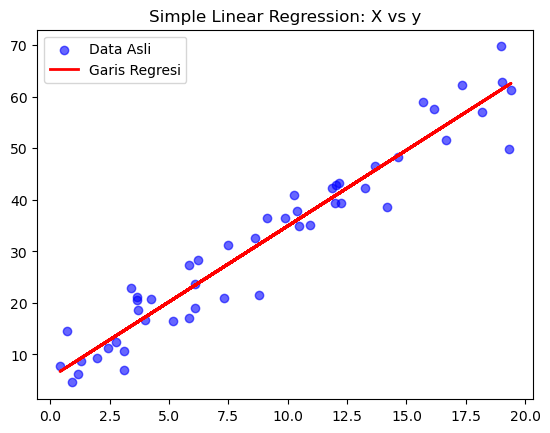

R2 Score: 0.9323
MAE: 3.6532
RMSE: 4.5362

Prediksi 5 nilai baru:
X = 5 => Prediksi y = 20.20
X = 10 => Prediksi y = 34.92
X = 15 => Prediksi y = 49.65
X = 20 => Prediksi y = 64.37
X = 25 => Prediksi y = 79.09


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== Tugas 1: Simple Linear Regression ===")
# 1. Buat dataset sendiri (y = 3x + 5)
np.random.seed(42)
X = np.random.rand(50, 1) * 20
y = 3 * X.squeeze() + 5 + np.random.randn(50) * 5

# 2. Scatter plot data
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Asli')

# 3. Implementasi Simple Linear Regression
model_simple = LinearRegression()
model_simple.fit(X, y)
y_pred = model_simple.predict(X)

# 4. Visualisasi regression line
plt.plot(X, y_pred, color='red', linewidth=2, label='Garis Regresi')
plt.title('Simple Linear Regression: X vs y')
plt.legend()
plt.show()

# 5. Hitung Metrik
print(f"R2 Score: {r2_score(y, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

# 6. Prediksi 5 nilai baru
X_new = np.array([[5], [10], [15], [20], [25]])
new_preds = model_simple.predict(X_new)
print("\nPrediksi 5 nilai baru:")
for val, pred in zip(X_new.flatten(), new_preds):
    print(f"X = {val} => Prediksi y = {pred:.2f}")
print("="*50)


=== Tugas 2: Multiple Linear Regression (House Prices) ===
Top 5 Fitur: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

R2 Score (Semua Fitur): 0.8227
R2 Score (Top 5 Fitur): 0.7916


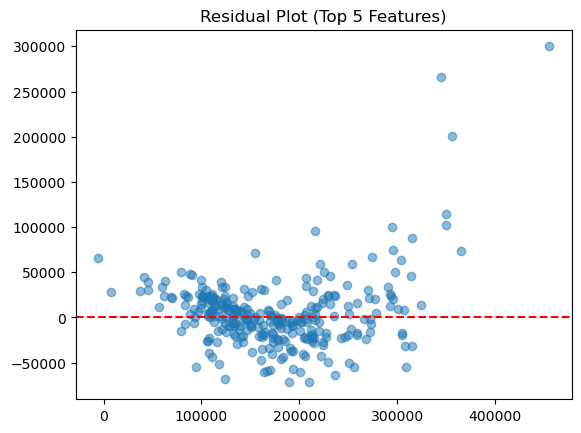

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("\n=== Tugas 2: Multiple Linear Regression (House Prices) ===")
df = pd.read_csv('train.csv')

# Ambil kolom numerik saja & handle missing
df_num = df.select_dtypes(include=[np.number]).fillna(df.median(numeric_only=True))

# Korelasi untuk feature selection
corr_target = df_num.corr()['SalePrice'].sort_values(ascending=False)
top_5_features = corr_target.index[1:6].tolist()
print(f"Top 5 Fitur: {top_5_features}")

# Split data
X = df_num.drop('SalePrice', axis=1)
y = df_num['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model A: Semua Fitur
model_all = LinearRegression().fit(X_train, y_train)
pred_all = model_all.predict(X_test)

# Model B: Top 5 Fitur
X_train_top = X_train[top_5_features]
X_test_top = X_test[top_5_features]
model_top = LinearRegression().fit(X_train_top, y_train)
pred_top = model_top.predict(X_test_top)

# Perbandingan
print(f"\nR2 Score (Semua Fitur): {r2_score(y_test, pred_all):.4f}")
print(f"R2 Score (Top 5 Fitur): {r2_score(y_test, pred_top):.4f}")

# Analisis Residuals (Model Top 5)
plt.scatter(pred_top, y_test - pred_top, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Top 5 Features)')
plt.show()
print("="*50)


=== Tugas 3: Polynomial Regression ===


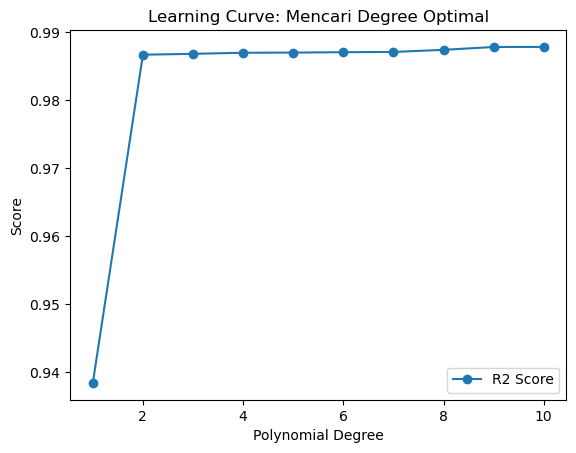

Derajat optimal biasanya berada di titik di mana kenaikan skor mulai mendatar (Degree 2).


In [3]:
from sklearn.preprocessing import PolynomialFeatures

print("\n=== Tugas 3: Polynomial Regression ===")
# Data non-linear
np.random.seed(0)
X_p = np.sort(np.random.rand(100, 1) * 10, axis=0)
y_p = 0.5 * X_p**2 + X_p + 2 + np.random.randn(100, 1) * 2

train_scores, test_scores = [], []
degrees = range(1, 11)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X_p)
    model = LinearRegression().fit(X_poly, y_p)
    train_scores.append(r2_score(y_p, model.predict(X_poly)))

# Visualisasi Learning Curve
plt.plot(degrees, train_scores, marker='o', label='R2 Score')
plt.xlabel('Polynomial Degree')
plt.ylabel('Score')
plt.title('Learning Curve: Mencari Degree Optimal')
plt.legend()
plt.show()
print("Derajat optimal biasanya berada di titik di mana kenaikan skor mulai mendatar (Degree 2).")
print("="*50)


=== Tugas 4: Aplikasi Prediksi Gaji ===


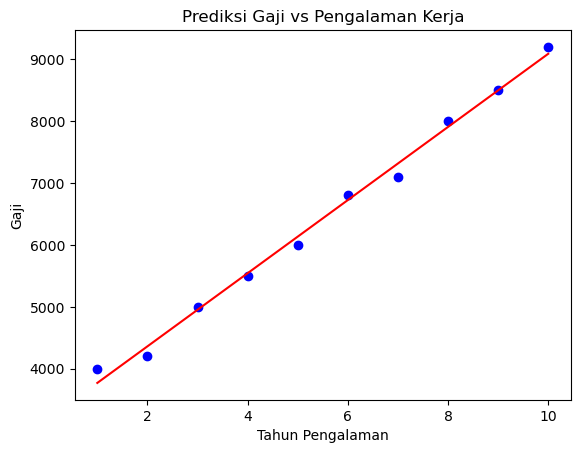

R2 Score Model Gaji: 0.9940
Kesimpulan: Model sangat baik karena R2 mendekati 1. Hubungan pengalaman dan gaji sangat linear.


In [4]:
print("\n=== Tugas 4: Aplikasi Prediksi Gaji ===")
# Simulasi Data Gaji
data_gaji = {
    'Tahun_Pengalaman': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Gaji': [4000, 4200, 5000, 5500, 6000, 6800, 7100, 8000, 8500, 9200]
}
df_gaji = pd.DataFrame(data_gaji)

X_g = df_gaji[['Tahun_Pengalaman']]
y_g = df_gaji['Gaji']

model_gaji = LinearRegression().fit(X_g, y_g)
gaji_pred = model_gaji.predict(X_g)

plt.scatter(X_g, y_g, color='blue')
plt.plot(X_g, gaji_pred, color='red')
plt.title('Prediksi Gaji vs Pengalaman Kerja')
plt.xlabel('Tahun Pengalaman'); plt.ylabel('Gaji')
plt.show()

print(f"R2 Score Model Gaji: {r2_score(y_g, gaji_pred):.4f}")
print("Kesimpulan: Model sangat baik karena R2 mendekati 1. Hubungan pengalaman dan gaji sangat linear.")